# Vitalia HAR — Kaggle Training Notebook

Entrena el modelo HAR (ResNet1D v2) con ciclismo (PAMAP2) y exporta TFLite para la app Flutter.

**Datasets a añadir a este notebook:**
1. `vitalia-har-processed` — tus archivos `.npy` de `data/processed/` (X, y, subjects)
2. `pamap2-physical-activity-monitoring` — datos PAMAP2 (opcional, para clase cycling)

**Output (`/kaggle/working/`):**
- `har_model_int8.tflite` — modelo cuantizado INT8 para Flutter
- `har_model_fp16.tflite` — modelo FP16
- `model_meta.json` — clases, métricas, tamaños
- `har_model.keras` — pesos completos Keras

In [70]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/jaimenovillo/pamap2-physical-activity-monitoring/subject103.dat
/kaggle/input/datasets/jaimenovillo/pamap2-physical-activity-monitoring/subject107.dat
/kaggle/input/datasets/jaimenovillo/pamap2-physical-activity-monitoring/subject106.dat
/kaggle/input/datasets/jaimenovillo/pamap2-physical-activity-monitoring/subject101.dat
/kaggle/input/datasets/jaimenovillo/pamap2-physical-activity-monitoring/subject102.dat
/kaggle/input/datasets/jaimenovillo/pamap2-physical-activity-monitoring/subject105.dat
/kaggle/input/datasets/jaimenovillo/pamap2-physical-activity-monitoring/subject109.dat
/kaggle/input/datasets/jaimenovillo/pamap2-physical-activity-monitoring/subject104.dat
/kaggle/input/datasets/jaimenovillo/pamap2-physical-activity-monitoring/subject108.dat
/kaggle/input/datasets/jaimenovillo/vitalia-har-processed/y_activities.npy
/kaggle/input/datasets/jaimenovillo/vitalia-har-processed/subjects_activities.npy
/kaggle/input/datasets/jaimenovillo/vitalia-har-processed/X_

In [71]:
import numpy as np
import pandas as pd
import os, math, shutil, json, warnings
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from scipy.signal import resample_poly, butter, filtfilt
from math import gcd

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

# Enable mixed precision for faster training on Kaggle T4/P100
tf.keras.mixed_precision.set_global_policy('mixed_float16')

WORKING_DIR = Path('/kaggle/working')
INPUT_DIR   = Path('/kaggle/input')

gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow {tf.__version__}')
print(f'GPU devices: {gpus}')
print(f'Mixed precision: {tf.keras.mixed_precision.global_policy().name}')

TensorFlow 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision: mixed_float16


In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────

# Set True if you added the vitalia-har-processed dataset (processed .npy files).
# Set False to load from raw UCI HAR + MotionSense datasets (slower).
LOAD_FROM_PROCESSED = True

# Run full LOSO (True) or skip it and just train final model (False).
# LOSO over 54+ subjects takes ~1-3 h on T4. Set False for fastest run.
RUN_LOSO = True

# Limit LOSO folds to this many subjects (None = all). Useful for quick checks.
QUICK_LOSO_SUBJECTS = None  # e.g. 10 for a fast check; None = all

# Minimum LOSO F1-macro required before saving new TFLite (fallback guard).
# Run anterior dio 0.9179, asi que 0.85 deja margen y el guard sigue protegiendo.
BASELINE_F1 = 0.85

# ── Paths ──────────────────────────────────────────────────────────────────────
# Processed .npy arrays (from notebook 01 / your local data/processed/ folder)
PROC_DATASET   = 'vitalia-har-processed'
PROC_DIR   = Path('/kaggle/input/datasets/jaimenovillo/vitalia-har-processed')

_pamap2_candidates = [
    Path('/kaggle/input/datasets/jaimenovillo/pamap2-physical-activity-monitoring'),
]
PAMAP2_DIR = next((p for p in _pamap2_candidates if p.exists()), None)

# Raw dataset paths (used only if LOAD_FROM_PROCESSED=False)
UCI_HAR_DIR    = INPUT_DIR / 'uci-har-dataset'
MOTIONSENSE_DIR = INPUT_DIR / 'motionsense'

print(f'PROC_DIR exists:    {PROC_DIR.exists()} → {PROC_DIR}')
print(f'PAMAP2_DIR found:   {PAMAP2_DIR}')
print(f'UCI_HAR_DIR exists: {UCI_HAR_DIR.exists()}')
print(f'MOTIONSENSE exists: {MOTIONSENSE_DIR.exists()}')

In [ ]:
# ── Inlined preprocessing functions (from src/preprocessing/windowing.py) ────

def resample_signal(data, orig_hz, target_hz=50):
    if orig_hz == target_hz:
        return data
    g = gcd(orig_hz, target_hz)
    return resample_poly(data, target_hz // g, orig_hz // g, axis=0).astype(np.float32)

def butterworth_lowpass(data, cutoff=20.0, fs=50.0, order=4):
    nyq = fs / 2.0
    b, a = butter(order, cutoff / nyq, btype='low', analog=False)
    return filtfilt(b, a, data, axis=0).astype(np.float32)

def highpass_gravity_removal(accel_g, fs=50.0):
    """Remove gravity from accel via 0.3 Hz high-pass (produces linear/body accel)."""
    b, a = butter(4, 0.3 / (fs / 2), btype='high')
    return filtfilt(b, a, accel_g, axis=0).astype(np.float32)

def sliding_window(data, window_size=128, overlap=0.5):
    step = int(window_size * (1.0 - overlap))
    starts = range(0, len(data) - window_size + 1, step)
    return np.stack([data[s:s+window_size] for s in starts], axis=0).astype(np.float32)

def augment_axis_permutation(window):
    perm  = np.random.permutation(3)
    signs = np.random.choice([-1, 1], size=3)
    aug = window.copy()
    aug[:, :3] = window[:, :3][:, perm] * signs
    aug[:, 3:6] = window[:, 3:6][:, perm] * signs
    return aug.astype(np.float32)

def augment_gaussian_noise(window, sigma=0.01):
    return (window + np.random.normal(0, sigma, window.shape)).astype(np.float32)

def augment_magnitude_scale(window, lo=0.8, hi=1.2):
    return (window * np.random.uniform(lo, hi)).astype(np.float32)

def augment_time_warp(window, ratio=0.1):
    n, c = window.shape
    factor = 1.0 + np.random.uniform(-ratio, ratio)
    new_len = max(1, int(n * factor))
    warped = resample_poly(window, new_len, n, axis=0)
    out = resample_poly(warped, n, new_len, axis=0)
    if len(out) >= n:
        return out[:n].astype(np.float32)
    return np.concatenate([out, np.zeros((n-len(out), c), dtype=np.float32)], axis=0)

def augment_window(window, n_augments=4):
    # FIX label-noise walking->running/cycling: SOLO axis-permutation (invarianza de
    # colocacion) + ruido gaussiano. Se QUITAN magnitude_scale y time_warp porque cambian
    # intensidad/cadencia = justo lo que separa walk/run/cycle. Aplicados a running/cycling
    # generaban muestras walk-like mal etiquetadas (smoke test: walking->run 0.29, ->cyc 0.14).
    # magnitude_scale / time_warp siguen definidas arriba por si se quieren reintroducir suaves.
    out = []
    for _ in range(n_augments):
        aug = window.copy()
        if np.random.rand() > 0.5: aug = augment_axis_permutation(aug)
        if np.random.rand() > 0.5: aug = augment_gaussian_noise(aug)
        out.append(aug)
    return out

print('Preprocessing functions loaded.')

In [74]:
# ── Raw dataset loaders (used only when LOAD_FROM_PROCESSED=False) ────────────

def load_uci_har(root: Path, window_size=128):
    """Load UCI HAR raw inertial signals.
    Expects: root/train/Inertial Signals/ and root/test/Inertial Signals/
    Returns (X, y_1indexed, subjects) where X shape = (N, 128, 6).
    """
    channels = ['body_acc_x', 'body_acc_y', 'body_acc_z',
                'body_gyro_x', 'body_gyro_y', 'body_gyro_z']
    Xs, ys, subjs = [], [], []
    for split in ['train', 'test']:
        sig_dir = root / split / 'Inertial Signals'
        if not sig_dir.exists():
            # Try alternative path (some Kaggle versions flatten the structure)
            sig_dir = root / 'Inertial Signals'
        if not sig_dir.exists():
            print(f'  WARNING: {sig_dir} not found, skipping UCI HAR {split} split')
            continue
        ch_data = []
        for ch in channels:
            path = sig_dir / f'{ch}_{split}.txt'
            if not path.exists():
                path = sig_dir / f'{ch}.txt'
            arr = np.loadtxt(path)  # (N, 128)
            ch_data.append(arr)
        X_split = np.stack(ch_data, axis=2).astype(np.float32)  # (N, 128, 6)
        y_split = np.loadtxt(root / split / f'y_{split}.txt', dtype=np.int32)
        s_split = np.loadtxt(root / split / f'subject_{split}.txt', dtype=np.int32)
        Xs.append(X_split)
        ys.append(y_split)
        subjs.append(s_split)
        print(f'  UCI HAR {split}: {len(X_split)} windows')
    return np.concatenate(Xs), np.concatenate(ys), np.concatenate(subjs)


def load_motionsense(root: Path, window_size=128, overlap=0.5):
    """Load MotionSense dataset (A_DeviceMotion_data/ structure).
    Returns (X, y_old_indexed, subjects) — y uses same old label convention:
    0=walking, 1=upstairs, 2=downstairs, 3=sitting, 4=standing, 5=running.
    """
    activity_map = {
        'wlk': 0,  # walking
        'ups': 1,  # upstairs
        'dws': 2,  # downstairs
        'sit': 3,  # sitting
        'std': 4,  # standing
        'jog': 5,  # running
    }
    data_dir = root / 'A_DeviceMotion_data'
    if not data_dir.exists():
        data_dir = root
    Xs, ys, subjs = [], [], []
    for act_prefix, act_label in activity_map.items():
        for folder in sorted(data_dir.glob(f'{act_prefix}_*')):
            for csv_file in sorted(folder.glob('sub_*.csv')):
                subj_id = int(csv_file.stem.split('_')[1])
                df = pd.read_csv(csv_file)
                cols_accel = ['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']
                cols_gyro  = ['rotationRate.x', 'rotationRate.y', 'rotationRate.z']
                # Handle column name variants
                if 'userAcceleration.x' not in df.columns:
                    cols_accel = [c for c in df.columns if 'userAcceleration' in c or 'userAcc' in c][:3]
                    cols_gyro  = [c for c in df.columns if 'rotation' in c.lower()][:3]
                sig = df[cols_accel + cols_gyro].values.astype(np.float32)
                if len(sig) < window_size:
                    continue
                wins = sliding_window(sig, window_size=window_size, overlap=overlap)
                Xs.append(wins)
                ys.append(np.full(len(wins), act_label, dtype=np.int32))
                subjs.append(np.full(len(wins), subj_id + 100, dtype=np.int32))
    if not Xs:
        raise RuntimeError(f'No MotionSense data found in {data_dir}')
    X = np.concatenate(Xs, axis=0)
    y = np.concatenate(ys, axis=0)
    s = np.concatenate(subjs, axis=0)
    print(f'MotionSense: {len(X)} windows, {len(np.unique(s))} subjects')
    return X, y, s


print('Raw dataset loaders defined.')

Raw dataset loaders defined.


In [ ]:
# ── Load UCI HAR + MotionSense ─────────────────────────────────────────────────
# Canonical class order (5 clases, cycling ELIMINADO — debe coincidir con har_classifier.dart):
#   0=static  1=walking  2=running  3=upstairs  4=downstairs
# Old UCI/MotionSense order: 0=walking,1=upstairs,2=downstairs,3=sitting,4=standing,5=running
_REMAP = {0: 1, 1: 3, 2: 4, 3: 0, 4: 0, 5: 2}  # sitting+standing → static(0); upstairs→3, downstairs→4

if LOAD_FROM_PROCESSED and PROC_DIR.exists():
    print('Loading preprocessed .npy arrays...')
    X        = np.load(PROC_DIR / 'X_activities.npy')        # (N, 128, 6)
    y_raw    = np.load(PROC_DIR / 'y_activities.npy')        # (N,) labels 1-6
    subjects = np.load(PROC_DIR / 'subjects_activities.npy') # (N,)
    # Convert 1-indexed → 0-indexed → canonical remapping
    y_0 = np.vectorize(_REMAP.get)(y_raw - 1).astype(np.int32)
    print(f'  Loaded: X={X.shape}, subjects={len(np.unique(subjects))}')

else:
    print('Loading from raw datasets...')
    X_parts, y_parts, subj_parts = [], [], []

    if UCI_HAR_DIR.exists():
        print('Loading UCI HAR...')
        X_u, y_u, s_u = load_uci_har(UCI_HAR_DIR)
        y_u_mapped = np.vectorize(_REMAP.get)(y_u - 1).astype(np.int32)
        X_parts.append(X_u); y_parts.append(y_u_mapped); subj_parts.append(s_u)
    else:
        print('WARNING: UCI HAR not found — add dataset uci-har-dataset')

    if MOTIONSENSE_DIR.exists():
        print('Loading MotionSense...')
        X_m, y_m, s_m = load_motionsense(MOTIONSENSE_DIR)
        y_m_mapped = np.vectorize(_REMAP.get)(y_m).astype(np.int32)
        X_parts.append(X_m); y_parts.append(y_m_mapped); subj_parts.append(s_m)
    else:
        print('WARNING: MotionSense not found — add dataset motionsense')

    if not X_parts:
        raise RuntimeError('No activity data found. Add vitalia-har-processed OR uci-har-dataset + motionsense.')

    X        = np.concatenate(X_parts, axis=0)
    y_0      = np.concatenate(y_parts, axis=0)
    subjects = np.concatenate(subj_parts, axis=0)
    print(f'Combined: X={X.shape}')

print(f'Main dataset: {len(X)} windows, {len(np.unique(subjects))} subjects')

In [ ]:
# ── Cycling DESACTIVADO ────────────────────────────────────────────────────────
# Cycling (PAMAP2, sensor de tobillo) ELIMINADO del modelo:
#  - placement gap: tobillo (PAMAP2) != movil de bolsillo -> no transfiere a uso real.
#  - alucinaba sobre walking (smoke test: walking->cycling 14%).
#  - solo 1278 ventanas de una fuente de dominio distinto.
# Modelo ahora 5 clases: static, walking, running, upstairs, downstairs.
# (La celda de carga PAMAP2 se conserva en git si se quiere reactivar cycling.)
CYCLING_LOADED = False
print('Cycling DESACTIVADO. Modelo de 5 clases (sin cycling).')

In [ ]:
# ── Class distribution ────────────────────────────────────────────────────────
import collections, matplotlib.pyplot as plt

N_CLASSES  = 5
CLASS_NAMES = ['static', 'walking', 'running', 'upstairs', 'downstairs']

print(f'Total windows: {len(X)}, subjects: {len(np.unique(subjects))}, cycling_loaded: {CYCLING_LOADED}')
print(f'X shape: {X.shape}  y_0 shape: {y_0.shape}')
print('\nClass distribution:')
dist = collections.Counter(y_0.tolist())
for i, name in enumerate(CLASS_NAMES):
    n = dist.get(i, 0)
    print(f'  {i} {name:12s}: {n:6d} windows {"(NO DATA)" if n == 0 else ""}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(CLASS_NAMES, [dist.get(i, 0) for i in range(N_CLASSES)], color='steelblue')
ax.set_title('Class distribution (before augmentation)')
ax.set_ylabel('Windows')
plt.tight_layout()
plt.savefig(WORKING_DIR / 'class_distribution.png', dpi=100)
plt.show()

In [78]:
# ── ResNet1D v2 architecture ───────────────────────────────────────────────────
# Input: (batch, 128, 6) — linear_accel_xyz + gyro_xyz @ 50 Hz
# Output: (batch, 6) — softmax class probabilities
# Same architecture and output shape as local notebook 03 — Flutter-compatible.

def build_har_model(n_classes=6, window_size=128, n_channels=6):
    inp = keras.Input(shape=(window_size, n_channels), name='sensor_input')

    x = L.Conv1D(64, 7, padding='same', use_bias=False, name='stem_conv')(inp)
    x = L.BatchNormalization(name='stem_bn')(x)
    x = L.Activation('relu', name='stem_act')(x)

    # Block 1 — 64 filters
    sc = x
    x = L.Conv1D(64, 3, padding='same', use_bias=False, name='r1_c1')(x)
    x = L.BatchNormalization(name='r1_bn1')(x)
    x = L.Activation('relu', name='r1_a1')(x)
    x = L.Conv1D(64, 3, padding='same', use_bias=False, name='r1_c2')(x)
    x = L.BatchNormalization(name='r1_bn2')(x)
    x = L.Add(name='r1_add')([x, sc])
    x = L.Activation('relu', name='r1_out')(x)
    x = L.MaxPooling1D(2, name='pool1')(x)

    # Block 2 — 128 filters (projection shortcut)
    sc = L.Conv1D(128, 1, padding='same', use_bias=False, name='r2_proj')(x)
    x = L.Conv1D(128, 3, padding='same', use_bias=False, name='r2_c1')(x)
    x = L.BatchNormalization(name='r2_bn1')(x)
    x = L.Activation('relu', name='r2_a1')(x)
    x = L.Conv1D(128, 3, padding='same', use_bias=False, name='r2_c2')(x)
    x = L.BatchNormalization(name='r2_bn2')(x)
    x = L.Add(name='r2_add')([x, sc])
    x = L.Activation('relu', name='r2_out')(x)
    x = L.MaxPooling1D(2, name='pool2')(x)

    # Block 3 — 256 filters (projection shortcut)
    sc = L.Conv1D(256, 1, padding='same', use_bias=False, name='r3_proj')(x)
    x = L.Conv1D(256, 3, padding='same', use_bias=False, name='r3_c1')(x)
    x = L.BatchNormalization(name='r3_bn1')(x)
    x = L.Activation('relu', name='r3_a1')(x)
    x = L.Conv1D(256, 3, padding='same', use_bias=False, name='r3_c2')(x)
    x = L.BatchNormalization(name='r3_bn2')(x)
    x = L.Add(name='r3_add')([x, sc])
    x = L.Activation('relu', name='r3_out')(x)

    x = L.GlobalAveragePooling1D(name='gap')(x)
    x = L.Dense(128, activation='relu', name='fc1', dtype='float32')(x)  # cast back for softmax
    x = L.Dropout(0.4, name='drop')(x)
    out = L.Dense(n_classes, activation='softmax', name='class_probs', dtype='float32')(x)

    return keras.Model(inp, out, name='HAR_ResNet1D_v2')

# Quick shape check
_m = build_har_model()
_m.summary()
del _m

Model: "HAR_ResNet1D_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None, 128, 6)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv1D)  │ (None, 128, 64)   │      2,688 │ sensor_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 64)   │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_act            │ (None, 128, 64)   │          0 │ stem_bn[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ r1_c1 (Conv1D)      │ (None, 128, 64)   │     12,288 │ stem_act[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ r1_bn1              │ (None, 128, 64)   │        256 │ r1_c1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ r1_a1 (Activation)  │ (None, 128, 64)   │          0 │ r1_bn1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ r1_c2 (Conv1D)      │ (None, 128, 64)   │     12,288 │ r1_a1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ r1_bn2              │ (None, 128, 64)   │        256 │ r1_c2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ r1_add (Add)        │ (None, 128, 64)   │          0 │ r1_bn2[0][0],     │
│                     │                   │            │ stem_act[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ r1_out (Activation) │ (None, 128, 64)   │          0 │ r1_add[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64)    │          0 │ r1_out[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ r2_c1 (Conv1D)      │ (None, 64, 128)   │     24,576 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ r2_bn1              │ (None, 64, 128)   │        512 │ r2_c1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ r2_a1 (Activation)  │ (None, 64, 128)   │          0 │ r2_bn1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ r2_c2 (Conv1D)      │ (None, 64, 128)   │     49,152 │ r2_a1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ r2_bn2              │ (None, 64, 128)   │        512 │ r2_c2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ r2_proj (Conv1D)    │ (None, 64, 128)   │      8,192 │ pool1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ r2_add (Add)        │ (None, 64, 128)   │          0 │ r2_bn2[0][0],     │
│                     │                   │            │ r2_proj[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ r2_out (Activation) │ (None, 64, 128)   │          0 │ r2_add[0][0]    

 Total params: 474,374 (1.81 MB)

 Trainable params: 472,454 (1.80 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
# ── Training helpers ───────────────────────────────────────────────────────────

# Canonical class order (5 clases): 0=static,1=walking,2=running,3=upstairs,4=downstairs
#
# FIX over-deteccion (v6 — sin cycling, sin aug de running):
# v5 (cycling fuera + aug suave) subio F1 0.63->0.77, pero walking recall sigue 0.48:
# fuga walking->running 26% (running precision 0.55 = SOBRE-detectado, recall 0.97).
# Running NO es minoria a reforzar: con ×3 quedaba ~= walking y robaba ventanas ambiguas.
# v6: SIN augmentacion. Distribucion natural -> walking (6997) >> running (2025), las
# ventanas walk/run ambiguas caen a walking. class_weight=None.
AUG_MULTIPLIERS = {0: 1, 1: 1, 2: 1, 3: 1, 4: 1}  # sin aug: distribucion natural
CLASS_WEIGHT = None

def augment_per_class(X_tr, y_tr):
    X_parts, y_parts = [X_tr], [y_tr]
    for cls, mult in AUG_MULTIPLIERS.items():
        if mult <= 1:
            continue
        idx = np.where(y_tr == cls)[0]
        if len(idx) == 0:
            continue
        for _ in range(mult - 1):
            wins = [augment_window(X_tr[i], n_augments=1)[0] for i in idx]
            X_parts.append(np.stack(wins))
            y_parts.append(np.full(len(idx), cls, dtype=y_tr.dtype))
    return np.concatenate(X_parts), np.concatenate(y_parts)

def cosine_lr(epoch, total=80, warmup=5, lr_max=1e-3, lr_min=1e-5):
    if epoch < warmup:
        return lr_max * (epoch + 1) / warmup
    t = (epoch - warmup) / (total - warmup)
    return float(lr_min + 0.5 * (lr_max - lr_min) * (1 + math.cos(math.pi * t)))

print(f'AUG_MULTIPLIERS: {AUG_MULTIPLIERS}')
print(f'CLASS_WEIGHT: {CLASS_WEIGHT}')

In [ ]:
# ── LOSO training ──────────────────────────────────────────────────────────────
# Tip: set RUN_LOSO=False (config cell) to skip and go straight to final model.

# Validacion rapida: testear SOLO ciertos sujetos (los que tenian el problema).
#   None                     -> todos (run oficial)
#   list, p.ej. [101,107,110,119,124] -> smoke test 5 folds (~8 min)
#   range, p.ej. range(101,125)       -> todos los MotionSense (24 folds, donde fallaba)
# Train SIEMPRE usa el resto de sujetos completo; solo cambia QUE sujetos se testean.
LOSO_ONLY_SUBJECTS = [101, 107, 110, 119, 124]

all_y_true, all_y_pred = [], []
loso_results = []
LOSO_N_SUBJECTS = 0

if RUN_LOSO:
    unique_subj = np.unique(subjects)
    if LOSO_ONLY_SUBJECTS is not None:
        sel = np.array(list(LOSO_ONLY_SUBJECTS))
        unique_subj = unique_subj[np.isin(unique_subj, sel)]
        print(f'LOSO_ONLY_SUBJECTS activo: testeando {list(unique_subj)}')
    elif QUICK_LOSO_SUBJECTS:
        unique_subj = unique_subj[:QUICK_LOSO_SUBJECTS]
        print(f'QUICK_LOSO_SUBJECTS={QUICK_LOSO_SUBJECTS}: running {len(unique_subj)} folds')

    print(f'Running LOSO over {len(unique_subj)} subjects...')

    for fold_i, test_subj in enumerate(unique_subj):
        test_mask  = subjects == test_subj
        train_mask = ~test_mask
        X_tr, y_tr = X[train_mask], y_0[train_mask]
        X_te, y_te = X[test_mask],  y_0[test_mask]

        X_tr, y_tr = augment_per_class(X_tr, y_tr)
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_tr, y_tr, test_size=0.1, stratify=y_tr, random_state=42)

        m = build_har_model(N_CLASSES)
        m.compile(
            optimizer=keras.optimizers.Adam(1e-3),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'],
        )
        m.fit(
            X_tr, y_tr, epochs=80, batch_size=128,
            validation_data=(X_val, y_val),
            class_weight=CLASS_WEIGHT,  # None: solo aug balancea minorias reales
            callbacks=[
                keras.callbacks.LearningRateScheduler(cosine_lr, verbose=0),
                keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, verbose=0),
            ],
            verbose=0,
        )
        y_pred = m.predict(X_te, verbose=0).argmax(axis=1)
        all_y_true.extend(y_te)
        all_y_pred.extend(y_pred)
        f1  = f1_score(y_te, y_pred, average='macro')
        acc = accuracy_score(y_te, y_pred)
        loso_results.append({'subject': int(test_subj), 'f1_macro': f1, 'accuracy': acc})
        print(f'  [{fold_i+1}/{len(unique_subj)}] subj {test_subj}: F1={f1:.3f} acc={acc:.3f}')
        del m

    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    LOSO_N_SUBJECTS = len(unique_subj)
    loso_f1 = f1_score(all_y_true, all_y_pred, average='macro')

    print(f'\nLOSO F1-macro (all folds): {loso_f1:.4f}')
    print(classification_report(all_y_true, all_y_pred,
      target_names=CLASS_NAMES, labels=list(range(N_CLASSES)), zero_division=0))

    # Matriz de confusion row-normalizada (a donde va cada clase real) — para diagnostico
    cm = confusion_matrix(all_y_true, all_y_pred, labels=list(range(N_CLASSES)))
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    print('Confusion (filas=real, cols=predicho, normalizado por fila):')
    print('            ' + ' '.join(f'{n[:5]:>6s}' for n in CLASS_NAMES))
    for i, name in enumerate(CLASS_NAMES):
        print(f'  {name:11s} ' + ' '.join(f'{cm_norm[i,j]:6.2f}' for j in range(N_CLASSES)))

    # Save LOSO results
    pd.DataFrame(loso_results).to_csv(WORKING_DIR / 'loso_results.csv', index=False)
    print('LOSO results saved to /kaggle/working/loso_results.csv')
else:
    print('LOSO skipped (RUN_LOSO=False). Training final model only.')
    loso_f1 = None

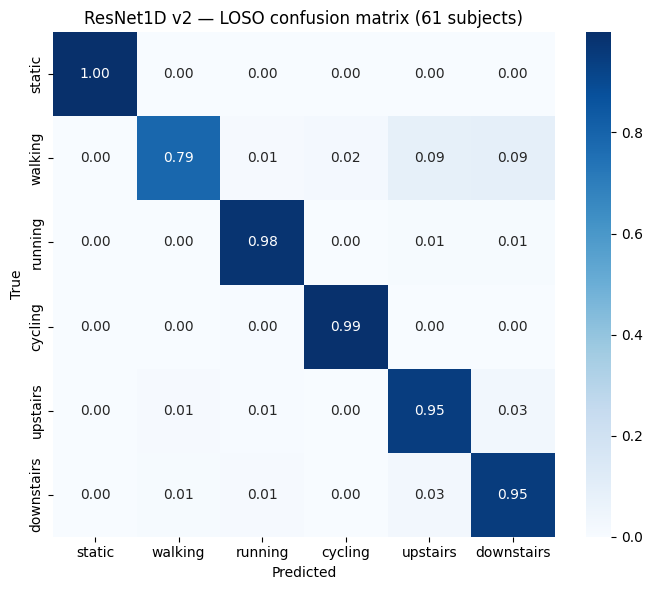

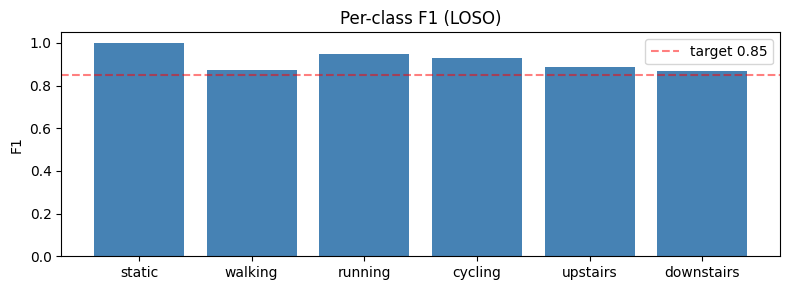

In [81]:
# ── Confusion matrix (only if LOSO ran) ───────────────────────────────────────
if RUN_LOSO and len(all_y_true) > 0:
    import seaborn as sns
    cm = confusion_matrix(all_y_true, all_y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'ResNet1D v2 — LOSO confusion matrix ({LOSO_N_SUBJECTS} subjects)')
    plt.tight_layout()
    plt.savefig(WORKING_DIR / 'confusion_matrix.png', dpi=120)
    plt.show()

    # Per-class F1 bar chart
    f1_per_class = f1_score(all_y_true, all_y_pred, average=None,
                        labels=list(range(N_CLASSES)), zero_division=0)
    fig, ax = plt.subplots(figsize=(8, 3))
    colors = ['red' if f < 0.80 else 'steelblue' for f in f1_per_class]
    ax.bar(CLASS_NAMES, f1_per_class, color=colors)
    ax.axhline(0.85, color='red', linestyle='--', alpha=0.5, label='target 0.85')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('F1')
    ax.set_title('Per-class F1 (LOSO)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(WORKING_DIR / 'f1_per_class.png', dpi=120)
    plt.show()

In [ ]:
# ── Final model — train on ALL data ──────────────────────────────────────────
print('Training final model on full dataset...')
X_full, y_full = augment_per_class(X, y_0)

unique_cls, cls_counts = np.unique(y_full, return_counts=True)
print('Post-augmentation class distribution:')
for cls, cnt in zip(unique_cls, cls_counts):
    print(f'  {CLASS_NAMES[cls]:12s}: {cnt:6d}')

X_full, X_val, y_full, y_val = train_test_split(
    X_full, y_full, test_size=0.05, stratify=y_full, random_state=42)
print(f'Train: {len(X_full)}  Val: {len(X_val)}')

final_model = build_har_model(N_CLASSES)
final_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
final_model.fit(
    X_full, y_full,
    epochs=80, batch_size=128,
    validation_data=(X_val, y_val),
    class_weight=CLASS_WEIGHT,  # None: solo aug balancea minorias reales
    callbacks=[
        keras.callbacks.LearningRateScheduler(cosine_lr, verbose=0),
        keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True, verbose=1),
        keras.callbacks.ModelCheckpoint(
            str(WORKING_DIR / 'har_model.keras'),
            save_best_only=True, monitor='val_accuracy', verbose=1),
    ],
    verbose=1,
)
print('Final Keras model saved to /kaggle/working/har_model.keras')

In [83]:
# ── TFLite export ──────────────────────────────────────────────────────────────
proceed = (loso_f1 is None) or (loso_f1 >= BASELINE_F1)
if not proceed:
    print(f'WARNING: LOSO F1 {loso_f1:.4f} < baseline {BASELINE_F1}. TFLite NOT exported.')
    print('Lower BASELINE_F1 in the config cell to force export.')
else:
    if loso_f1 is not None:
        print(f'LOSO F1 {loso_f1:.4f} ≥ {BASELINE_F1}. Exporting TFLite...')
    else:
        print('LOSO skipped. Exporting TFLite unconditionally...')

    # Rebuild model in float32 — mixed_float16 stores Conv weights as f16,
    # which TFLite INT8 converter can't handle.
    tf.keras.mixed_precision.set_global_policy('float32')
    float32_weights = [w.astype(np.float32) for w in final_model.get_weights()]
    final_model = build_har_model(N_CLASSES)
    final_model.set_weights(float32_weights)
    print('Model rebuilt in float32.')

    # ── INT8 ──────────────────────────────────────────────────────────────────
    converter = tf.lite.TFLiteConverter.from_keras_model(final_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    def representative_dataset():
        idx = np.random.choice(len(X), size=min(400, len(X)), replace=False)
        for i in idx:
            yield [X[i:i+1].astype(np.float32)]

    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type  = tf.int8
    converter.inference_output_type = tf.int8

    tflite_int8 = converter.convert()
    out_int8 = WORKING_DIR / 'har_model_int8.tflite'
    out_int8.write_bytes(tflite_int8)
    print(f'INT8 → {out_int8} ({len(tflite_int8)/1024:.1f} KB)')

    # ── FP16 ──────────────────────────────────────────────────────────────────
    converter2 = tf.lite.TFLiteConverter.from_keras_model(final_model)
    converter2.optimizations = [tf.lite.Optimize.DEFAULT]
    converter2.target_spec.supported_types = [tf.float16]
    tflite_fp16 = converter2.convert()
    out_fp16 = WORKING_DIR / 'har_model_fp16.tflite'
    out_fp16.write_bytes(tflite_fp16)
    print(f'FP16 → {out_fp16} ({len(tflite_fp16)/1024:.1f} KB)')

    # ── Verify INT8 ───────────────────────────────────────────────────────────
    interp = tf.lite.Interpreter(model_content=tflite_int8)
    interp.allocate_tensors()
    in_det  = interp.get_input_details()[0]
    out_det = interp.get_output_details()[0]
    print(f'INT8 input:  {in_det["shape"]} dtype={in_det["dtype"]}')
    print(f'INT8 output: {out_det["shape"]} dtype={out_det["dtype"]}')
    assert out_det['shape'][1] == N_CLASSES, 'Output class count mismatch!'

LOSO F1 0.9179 ≥ 0.1. Exporting TFLite...
Model rebuilt in float32.
INFO:tensorflow:Assets written to: /tmp/tmp0vvhg_eb/assets


INFO:tensorflow:Assets written to: /tmp/tmp0vvhg_eb/assets


Saved artifact at '/tmp/tmp0vvhg_eb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='sensor_input')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  140000631979088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587467664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587469200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139994062164176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587466704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587469584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587467088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587466896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587469392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587468432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587467472: Te

W0000 00:00:1780160996.587016      58 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780160996.588455      58 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


INT8 → /kaggle/working/har_model_int8.tflite (515.1 KB)
INFO:tensorflow:Assets written to: /tmp/tmp_yglnhx6/assets


INFO:tensorflow:Assets written to: /tmp/tmp_yglnhx6/assets


Saved artifact at '/tmp/tmp_yglnhx6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='sensor_input')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  140000631979088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587467664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587469200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139994062164176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587466704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587469584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587467088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587466896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587469392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587468432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139993587467472: Te

W0000 00:00:1780161000.198270      58 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780161000.198297      58 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


In [ ]:
# ── Save model metadata ────────────────────────────────────────────────────────
# model_meta.json is read by the Flutter app's ModelUpdateService.

meta = {
    'class_names': CLASS_NAMES,
    'n_classes': N_CLASSES,
    'window_size': 128,
    'overlap': 0.5,
    'target_hz': 50,
    'channels': ['lax', 'lay', 'laz', 'gx', 'gy', 'gz'],
    'cycling_trained': CYCLING_LOADED,
    'loso_f1_macro': round(float(loso_f1), 4) if loso_f1 is not None else None,
    'loso_n_subjects': LOSO_N_SUBJECTS,
    'training_windows': int(len(X)),
    'vitapoints_per_min': {
        'static': 0, 'walking': 2, 'running': 5,
        'upstairs': 3, 'downstairs': 2
    },
}
if proceed:
    meta['int8_size_kb'] = round(len(tflite_int8) / 1024, 1)
    meta['fp16_size_kb'] = round(len(tflite_fp16) / 1024, 1)

(WORKING_DIR / 'model_meta.json').write_text(json.dumps(meta, indent=2))
print('model_meta.json saved.')

# ── Final summary ──────────────────────────────────────────────────────────────
print('\n' + '='*55)
print('VITALIA HAR TRAINING COMPLETE')
print('='*55)
print(f'  Classes     : {", ".join(CLASS_NAMES)}')
print(f'  Cycling     : {CYCLING_LOADED}')
print(f'  LOSO F1     : {loso_f1:.4f} ({LOSO_N_SUBJECTS} subjects)' if loso_f1 else '  LOSO        : skipped')
print(f'  TFLite out  : {proceed}')
if proceed:
    print(f'  INT8 size   : {meta["int8_size_kb"]} KB')
    print(f'  FP16 size   : {meta["fp16_size_kb"]} KB')
print('\nFiles in /kaggle/working/:')
for f in sorted(WORKING_DIR.iterdir()):
    print(f'  {f.name} ({f.stat().st_size/1024:.1f} KB)')

## Usar el modelo en Flutter

Tras descargar el output de Kaggle:

```bash
# 1. Copiar TFLite al proyecto Flutter
cp har_model_int8.tflite app/assets/models/har_model_int8.tflite
cp har_model_fp16.tflite app/assets/models/har_model_fp16.tflite

# 2. El enum Activity en har_classifier.dart debe coincidir con class_names:
# stationary(0), walking(1), running(2), cycling(3), upstairs(4), downstairs(5)

# 3. Compilar y ejecutar
cd app && flutter run
```

**Nota de placement:** la clase `cycling` fue entrenada con datos del sensor de tobillo (PAMAP2), no de bolsillo. La augmentación de ejes mitiga la diferencia. Documentado como limitación conocida en docs/PLAN.md.